# Mushroom Classification

## Introduction

This notebook explores the [UCI Mushroom Classification dataset](https://www.kaggle.com/datasets/uciml/mushroom-classification), which describes 8,124 mushroom samples across 22 categorical physical attributes (cap shape, odor, gill color, habitat, and so on). Each sample is labeled as either **edible** or **poisonous**.

The goal is to build a model that predicts whether a mushroom is edible or poisonous from its observable characteristics. Because misclassifying a poisonous mushroom as edible is far more costly than the reverse error, the analysis will pay particular attention to false negatives (poisonous mushrooms predicted as edible) in addition to overall accuracy.

The notebook walks through the analysis in stages: exploratory data analysis, preprocessing, modeling, evaluation, and interpretation of the results.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd()))
from src.data import load_mushrooms

X, y = load_mushrooms()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
print("\nClass counts (0 = edible, 1 = poisonous):")
print(y.value_counts())

X shape: (8124, 21)
y shape: (8124,)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,s,w,w,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,s,w,w,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,s,w,w,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,s,w,w,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,s,w,w,w,o,e,n,a,g



Class counts (0 = edible, 1 = poisonous):
poisonous
0    4208
1    3916
Name: count, dtype: int64


## Feature association with the target

All features here are categorical, so we measure each one's association with
`class` using **Cramer's V** (built on the chi-square test of independence),
which ranges from 0 (independent) to 1 (perfectly determined). We also run
the chi-square test itself to check whether each association is statistically
significant.

In [2]:
from src.eda import association_table, plot_association_ranking

assoc = association_table(X, y)
assoc.style.format({"cramers_v": "{:.3f}", "chi2": "{:.1f}", "p_value": "{:.2e}"})

,cramers_v,chi2,dof,p_value
feature,,,,
odor,0.971,7659.7,8,0.00e+00
spore-print-color,0.753,4602.0,8,0.00e+00
gill-color,0.681,3765.7,11,0.00e+00
ring-type,0.603,2956.6,4,0.00e+00
stalk-surface-above-ring,0.588,2808.3,3,0.00e+00
stalk-surface-below-ring,0.575,2684.5,3,0.00e+00
gill-size,0.540,2369.2,1,0.00e+00
stalk-color-above-ring,0.525,2237.9,8,0.00e+00
stalk-color-below-ring,0.515,2152.4,8,0.00e+00


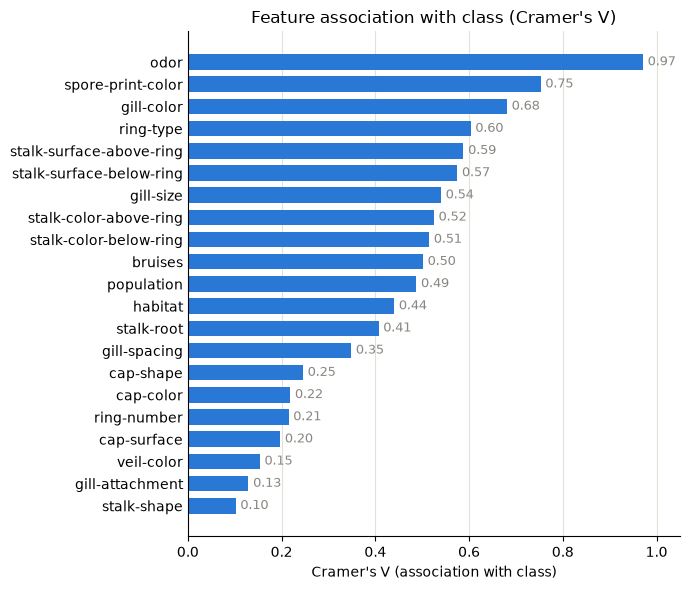

In [3]:
import matplotlib.pyplot as plt

ax = plot_association_ranking(assoc)
ax.set_title("Feature association with class (Cramer's V)")
plt.tight_layout()
plt.show()

In [4]:
print(f"Features with a significant chi-square result (p < 0.05): "
      f"{(assoc['p_value'] < 0.05).sum()} / {len(assoc)}")
assoc[["chi2", "dof", "p_value"]]

Features with a significant chi-square result (p < 0.05): 21 / 21


,chi2,dof,p_value
feature,,,
odor,7659.726740,8,0.000000e+00
spore-print-color,4602.033170,8,0.000000e+00
gill-color,3765.714086,11,0.000000e+00
ring-type,2956.619278,4,0.000000e+00
stalk-surface-above-ring,2808.286287,3,0.000000e+00
stalk-surface-below-ring,2684.474076,3,0.000000e+00
gill-size,2369.172115,1,0.000000e+00
stalk-color-above-ring,2237.898496,8,0.000000e+00
stalk-color-below-ring,2152.390891,8,0.000000e+00


**Interpretation**

- `odor` is by far the strongest single predictor of `class` (Cramer's V close to
  1), followed by `spore-print-color`, `gill-color`, and `ring-type`. These
  features alone separate most edible from poisonous samples.
- `stalk-shape`, `gill-attachment`, `veil-color`, and `cap-surface` are the
  weakest features, with Cramer's V well below 0.2 — they carry little
  information about edibility on their own.
- Every feature's chi-square test is significant at p < 0.05, which is
  expected with over 8,000 samples: statistical significance here mainly
  reflects sample size, not practical importance. **Cramer's V, not the
  p-value, is what should drive judgments of feature strength.**
- These are associations, not causal effects. `odor` predicting `class` well
  says nothing about *why* a mushroom is poisonous — only that the two vary
  together in this dataset.

## Preprocessing and train/test split

Before any modeling, we set aside a held-out test set and decide how the
categorical features will be encoded. The test set is not touched again
until final evaluation.

In [5]:
from src.preprocessing import split_data

X_train, X_test, y_train, y_test = split_data(X, y)

print(f"{'':10}{'X shape':>12}{'y shape':>12}{'% poisonous':>14}")
print(f"{'train':10}{str(X_train.shape):>12}{str(y_train.shape):>12}{y_train.mean() * 100:>13.2f}%")
print(f"{'test':10}{str(X_test.shape):>12}{str(y_test.shape):>12}{y_test.mean() * 100:>13.2f}%")

               X shape     y shape   % poisonous
train       (6499, 21)     (6499,)        48.21%
test        (1625, 21)     (1625,)        48.18%


In [6]:
from src.preprocessing import build_encoder

# Fit only to check the resulting feature count - the encoder used for
# modeling will be fit fresh, inside each model's pipeline.
n_encoded = build_encoder().fit_transform(X_train).shape[1]
print(f"One-hot encoding {X_train.shape[1]} categorical columns "
      f"produces {n_encoded} encoded features.")

One-hot encoding 21 categorical columns produces 116 encoded features.


**Notes**

- **One-hot encoding** is appropriate because every feature is nominal (e.g.
  `cap-color` codes have no natural order), so encodings like ordinal integers
  would introduce a false sense of ranking that a linear model could pick up
  on. One-hot encoding treats each category as its own independent flag.
- **Fitting only on training data** means the set of known categories (and any
  encoder statistics) come only from `X_train`. If the encoder saw the test
  set first, information about which categories exist there would leak into
  training - an optimistic bias that would not hold up on truly new data.
  `handle_unknown="ignore"` is what makes this safe: a category the encoder
  never saw (rare, or only present in the test fold) is encoded as all zeros
  instead of raising an error. In later steps, the encoder is fit inside each
  model's pipeline, on the training fold only.
- **Stratification** matters even with a fairly balanced target because a
  plain random split can still shuffle the ~52/48 split into something more
  skewed by chance, especially for the rarer categories within individual
  features (some appear in only a handful of rows). Stratifying on `class`
  keeps the train and test proportions matched to the full dataset, so
  metrics on the test set aren't distorted by an accidental class imbalance.

## Modeling

We fit six models, each wrapped in a pipeline that handles its own encoding
so nothing is ever fit on the test set. This step only sets up and fits the
models on the training data - comparison and evaluation on the held-out test
set come next.

| Model | Why it's included |
|---|---|
| **Dummy (majority class)** | The floor: always predicts "edible". Any real model must clearly beat this. |
| **Odor-only** | EDA found `odor` alone has Cramer's V ≈ 0.97 with the target. This checks how far that single, easy-to-observe feature gets on its own. |
| **Categorical Naive Bayes** | Models each feature's per-category probabilities directly, which fits categorical data more naturally than one-hot encoding does. |
| **Logistic Regression** | A linear baseline whose coefficients can be read directly to see which categories push toward "poisonous". |
| **Decision Tree** | Learns explicit if/then rules that can be inspected and sanity-checked against domain knowledge (e.g. "if odor is foul, then poisonous"). |
| **Random Forest** | An ensemble of trees, to check whether extra capacity improves on a single decision tree. |

In [7]:
from src.modeling import build_all_pipelines

models = build_all_pipelines()

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    print(f"{name:30s} fitted")

Dummy (majority class)         fitted
Odor-only                      fitted
Categorical Naive Bayes        fitted
Logistic Regression            fitted


Decision Tree                  fitted


Random Forest                  fitted


## Evaluation

We evaluate all six fitted models two ways: **stratified 5-fold cross-validation
on the training set** (to see how stable each model is across folds) and a
**single pass on the held-out test set** (the final, unbiased check). Since
`class` is encoded as poisonous = 1, precision/recall/F1 below are with
respect to *predicting poisonous* - a **false negative** means a poisonous
mushroom predicted edible, the mistake this task cares about most.

### Cross-validation on the training set

In [8]:
from src.evaluation import cross_validate_models

cv_results = cross_validate_models(models, X_train, y_train)
mean_cols = [c for c in cv_results.columns if c.endswith("_mean")]
cv_results[mean_cols].rename(columns=lambda c: c.removesuffix("_mean")).style.format("{:.4f}")

/home/user/miniconda3/envs/cmpe255/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/miniconda3/envs/cmpe255/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/user/miniconda3/envs/cmpe255/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Dummy (majority class),0.5179,0.0000,0.0000,0.0000,0.5000
Odor-only,0.9851,1.0000,0.9690,0.9843,0.9874
Categorical Naive Bayes,0.9494,0.9933,0.9011,0.9448,0.9975
Logistic Regression,0.9994,1.0000,0.9987,0.9994,1.0000
Decision Tree,0.9997,1.0000,0.9994,0.9997,0.9997
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000


### Held-out test set

In [9]:
from src.evaluation import evaluate_on_test, plot_confusion_matrices

test_results, confusion_matrices = evaluate_on_test(models, X_test, y_test)
test_results.style.format({
    "accuracy": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}",
    "f1": "{:.4f}", "roc_auc": "{:.4f}",
})

,accuracy,precision,recall,f1,roc_auc,false_negatives,false_positives
model,,,,,,,
Dummy (majority class),0.5182,0.0000,0.0000,0.0000,0.5000,783,0
Odor-only,0.9858,1.0000,0.9706,0.9851,0.9882,23,0
Categorical Naive Bayes,0.9458,0.9901,0.8966,0.9410,0.9972,81,7
Logistic Regression,0.9994,1.0000,0.9987,0.9994,1.0000,1,0
Decision Tree,0.9988,1.0000,0.9974,0.9987,0.9990,2,0
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0,0


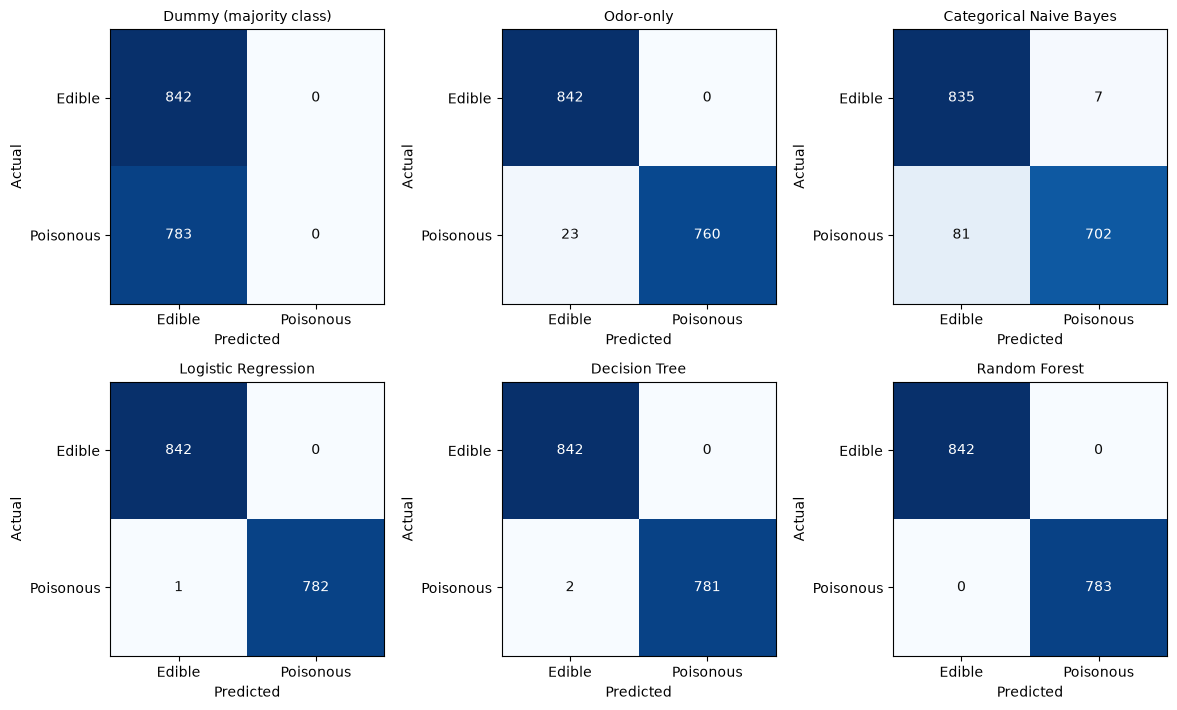

In [10]:
fig = plot_confusion_matrices(confusion_matrices)
plt.show()

In [11]:
n_poisonous_test = int(y_test.sum())
fn_summary = test_results[["false_negatives", "false_positives"]].copy()
fn_summary["fn_rate_of_poisonous"] = fn_summary["false_negatives"] / n_poisonous_test
fn_summary.style.format({"fn_rate_of_poisonous": "{:.2%}"})

,false_negatives,false_positives,fn_rate_of_poisonous
model,,,
Dummy (majority class),783,0,100.00%
Odor-only,23,0,2.94%
Categorical Naive Bayes,81,7,10.34%
Logistic Regression,1,0,0.13%
Decision Tree,2,0,0.26%
Random Forest,0,0,0.00%


**Interpretation**

- **Random Forest is the only model with zero errors** on both cross-validation
  and the test set (100% accuracy, precision, recall, F1, and ROC-AUC). Logistic
  Regression and the Decision Tree are close behind, each missing only 1-2
  poisonous mushrooms out of 783 in the test set.
- **The simple models are already very competitive.** The single-feature
  odor-only model reaches ~98.6% test accuracy and a perfect ROC-AUC of
  ~0.987, with only 23 false negatives - all without touching the other 20
  features. Categorical Naive Bayes does noticeably worse (~94.6% accuracy, 81
  false negatives) despite using every feature, because its independence
  assumption doesn't hold well here (see the feature-redundancy findings in
  the EDA section).
- **False negatives are what separate a "good" model from a "safe" one.**
  Accuracy alone would make Categorical Naive Bayes look reasonable (94.6%),
  but its 81 missed poisonous mushrooms (about 10% of poisonous test samples)
  make it unsuitable for this task. Random Forest, Logistic Regression, and
  the Decision Tree are the only candidates worth considering further, since
  they leave 0-2 poisonous mushrooms misclassified as edible.
- **The Dummy baseline confirms the task isn't trivially easy without
  information** (51.8% accuracy, 783 false negatives - it calls every
  poisonous mushroom edible), which puts the other models' scores in
  context.
- Cross-validation and test-set results agree closely for every model, so
  there's no sign of overfitting to a lucky split.

## Model interpretation and ablations

Having seen *how well* each model performs, we now look at *why*: which
features Logistic Regression, the Decision Tree, and Random Forest actually
rely on, whether they agree, and how performance changes when the strongest
features are removed.

### Logistic Regression coefficients

Each one-hot category gets its own coefficient. A positive value pushes the
prediction toward poisonous; negative pushes toward edible.

In [12]:
from src.interpretation import top_logistic_regression_coefficients

top_logistic_regression_coefficients(models["Logistic Regression"], top_n=10).style.format({"coefficient": "{:+.2f}"})

,feature,coefficient
encoded_feature,,
odor_n,odor,-4.01
spore-print-color_r,spore-print-color,+3.37
odor_f,odor,+2.75
odor_l,odor,-2.64
odor_c,odor,+2.59
odor_a,odor,-2.57
stalk-root_b,stalk-root,+2.48
gill-size_n,gill-size,+2.21
gill-size_b,gill-size,-2.12


### Decision Tree rules

The top of the tree (depth 3) - each split is an if/then rule on one one-hot
category.

In [13]:
from src.interpretation import decision_tree_rules

print(decision_tree_rules(models["Decision Tree"], max_depth=3))

|--- odor_n <= 0.50
|   |--- stalk-root_c <= 0.50
|   |   |--- stalk-surface-below-ring_y <= 0.50
|   |   |   |--- odor_a <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- odor_a >  0.50
|   |   |   |   |--- class: 0
|   |   |--- stalk-surface-below-ring_y >  0.50
|   |   |   |--- class: 0
|   |--- stalk-root_c >  0.50
|   |   |--- bruises_f <= 0.50
|   |   |   |--- class: 0
|   |   |--- bruises_f >  0.50
|   |   |   |--- class: 1
|--- odor_n >  0.50
|   |--- spore-print-color_r <= 0.50
|   |   |--- stalk-surface-below-ring_y <= 0.50
|   |   |   |--- cap-surface_g <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- cap-surface_g >  0.50
|   |   |   |   |--- class: 1
|   |   |--- stalk-surface-below-ring_y >  0.50
|   |   |   |--- ring-number_o <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- ring-number_o >  0.50
|   |   |   |   |--- class: 1
|   |--- spore-print-color_r >  0.50
|   |   |--- class: 1



### Random Forest feature importance

Importance per one-hot category, summed back up to its original feature.

In [14]:
from src.interpretation import random_forest_feature_importance

random_forest_feature_importance(models["Random Forest"]).head(8).rename("importance").to_frame().style.format("{:.3f}")

,importance
odor,0.227
gill-size,0.121
spore-print-color,0.094
stalk-surface-above-ring,0.089
ring-type,0.062
stalk-surface-below-ring,0.060
stalk-root,0.053
gill-color,0.045


### Which features are consistently important?

Ranking each feature's position (1 = most important) in each model's own
top 5, to see how much the three models agree.

In [15]:
from src.interpretation import (
    logistic_regression_feature_importance,
    decision_tree_feature_importance,
    compare_top_features,
)

rankings = {
    "Logistic Regression": logistic_regression_feature_importance(models["Logistic Regression"]),
    "Decision Tree": decision_tree_feature_importance(models["Decision Tree"]),
    "Random Forest": random_forest_feature_importance(models["Random Forest"]),
}
compare_top_features(rankings, top_n=5)

,Logistic Regression,Decision Tree,Random Forest,in_top_n_count
spore-print-color,2.0,4.0,3.0,3
odor,1.0,1.0,1.0,3
stalk-root,4.0,2.0,NaN,2
bruises,NaN,5.0,NaN,1
cap-color,5.0,NaN,NaN,1
gill-color,3.0,NaN,NaN,1
ring-type,NaN,NaN,5.0,1
gill-size,NaN,NaN,2.0,1
stalk-surface-above-ring,NaN,NaN,4.0,1
stalk-surface-below-ring,NaN,3.0,NaN,1


### Ablations

`odor` and `spore-print-color` are the two features every model agrees are
important. We check what happens to performance when they're removed,
using a Random Forest (the strongest full-feature model) as the "full
model" for these ablations:

1. **Odor-only** - the single-feature baseline already fit above.
2. **Full model without `odor`** - can the remaining 20 features compensate?
3. **Full model without `odor` and `spore-print-color`** - remove the two
   strongest features together.

In [16]:
from src.modeling import build_random_forest_on_columns

all_columns = list(X_train.columns)
columns_no_odor = [c for c in all_columns if c != "odor"]
columns_no_odor_spore = [c for c in columns_no_odor if c != "spore-print-color"]

ablation_models = {
    "Odor-only": models["Odor-only"],
    "Full without odor (RF)": build_random_forest_on_columns(columns_no_odor).fit(X_train, y_train),
    "Full without odor & spore-print-color (RF)": build_random_forest_on_columns(columns_no_odor_spore).fit(X_train, y_train),
    "Full model, reference (RF)": models["Random Forest"],
}

ablation_results, _ = evaluate_on_test(ablation_models, X_test, y_test)
ablation_results[["accuracy", "recall", "f1", "false_negatives", "false_positives"]].style.format({
    "accuracy": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}",
})

,accuracy,recall,f1,false_negatives,false_positives
model,,,,,
Odor-only,0.9858,0.9706,0.9851,23,0
Full without odor (RF),1.0000,1.0000,1.0000,0,0
Full without odor & spore-print-color (RF),1.0000,1.0000,1.0000,0,0
"Full model, reference (RF)",1.0000,1.0000,1.0000,0,0


**Interpretation**

- **Odor and spore-print-color dominate, and every model agrees on it.**
  `odor` ranks #1 in Logistic Regression, the Decision Tree, and Random
  Forest importances alike, and `spore-print-color` sits in the top 5 for
  all three - the only two features every model treats as important. Beyond
  those two, the models diverge on which secondary features matter
  (`stalk-root`, `gill-size`, `bruises`, `ring-type` each show up for some
  models but not others), which fits the strong feature-to-feature
  correlations found in the EDA section (e.g. `gill-attachment` overlapping
  heavily with the stalk-color and veil-color columns) - several features
  carry overlapping information, so which one a model "picks" can vary.
- **A single feature is a strong but imperfect predictor.** The odor-only
  model reaches 98.6% test accuracy but still misses 23 poisonous mushrooms
  (97.1% recall) - odor alone can't distinguish every case, most notably the
  `odor = none` mushrooms, which EDA showed are a mix of edible and
  poisonous.
- **The dataset is redundant enough that removing the top features costs
  nothing for a flexible model.** A Random Forest trained without `odor`,
  and even without both `odor` and `spore-print-color`, still reaches 100%
  test accuracy with zero false negatives - identical to the full model. The
  remaining features contain enough overlapping signal (e.g.
  `stalk-surface-above-ring`, `gill-color`, `ring-type`) to fully recover
  what `odor` and `spore-print-color` would have provided.
- **Practical takeaway:** no single feature is *necessary* for a strong
  model here, but `odor` is by far the most *efficient* one - it gets close
  to perfect with a fraction of the complexity. A tree-based model that can
  combine many features remains the safer choice when the goal is zero
  false negatives, since it isn't reliant on any one measurement being
  available or correctly read.